# Task 0: Course Project Dataset Exploration

### a) My Dataset
**Dataset:** Superstore Sales Dataset
**Source:** https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

### b) Description
This dataset contains data about the fictional US-based retailer "Superstore". It includes several different variables such as Order Date, Ship Mode, Customer Segment, Product Category, Sub-Category, Sales, Profit, and Region. It has around 10,000 rows. I am planning to do some kind of explortaion on profitability of the different product categories and regions (not 100% yet). 

### c) Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Preview the data
display(df.head())

Matplotlib is building the font cache; this may take a moment.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


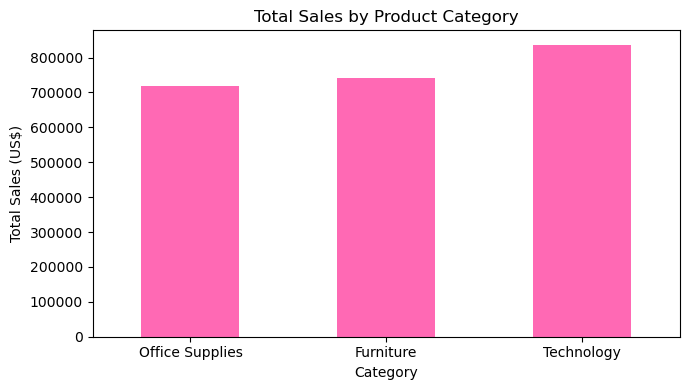

In [6]:
# Visualizations
# 1: Sales by Category 
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(7, 4))
sales_by_category.plot(kind='bar', color='hotpink')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales (US$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

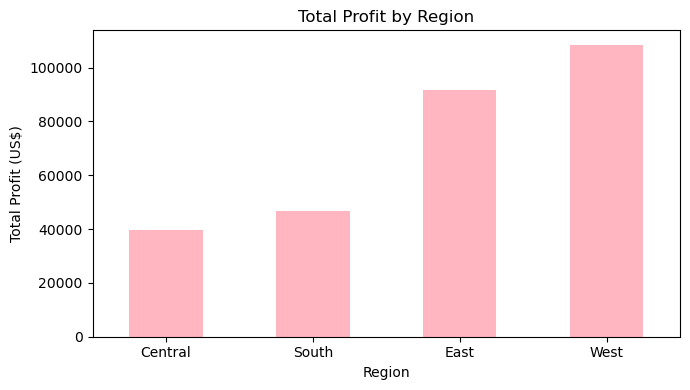

In [7]:
# 2: Profit by region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(7, 4))
profit_by_region.plot(kind='bar', color='lightpink')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit (US$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Task 1: Setting up an API key and .env file

In [16]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

# Print the first 5 characters
print(api_key[:5] + "...")

a358c...


# Task 2: Retrieving data from MarketStack

In [22]:
import requests

# a) Retrieve eod data

tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

all_data = []

for ticker in tickers:
    url = f"https://api.marketstack.com/v1/eod"
    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31"
    }
    response = requests.get(url, params=params)
    data = response.json()
    all_data.extend(data["data"])

In [20]:
# b) Convert to DataFrame
df_stocks = pd.DataFrame(all_data)

# Print first 5 rows
display(df_stocks.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


In [24]:
# c) Summary stats
summary = df_stocks.groupby('symbol')['close'].describe()
display(summary)

# Return percentage for each stock 
returns = df_stocks.groupby('symbol')['close'].agg(['first', 'last'])
returns['return_%'] = ((returns['last'] - returns['first']) / returns['first']) * 100
print
display(returns)

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


,first,last,return_%
symbol,,,
AAPL,253.79,264.72,4.306710
AMZN,208.27,208.39,0.057618
GOOG,286.86,306.36,6.797741
META,572.13,653.56,14.232779
NFLX,96.15,97.09,0.977639


In [26]:
# Best and worst performing stocks in March 2026
best = returns['return_%'].idxmax()
worst = returns['return_%'].idxmin()

print(f"\nBest performing stock: {best} ({returns.loc[best, 'return_%']:.2f}%)")
print(f"Worst performing stock: {worst} ({returns.loc[worst, 'return_%']:.2f}%)")


Best performing stock: META (14.23%)
Worst performing stock: AMZN (0.06%)


# Task 3: Visualizing stock data

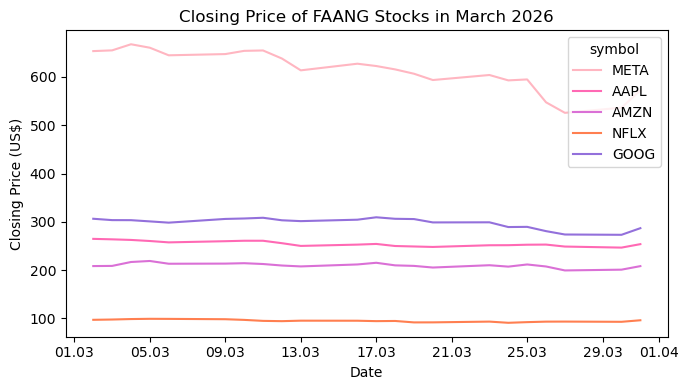

In [49]:
import seaborn as sns
import matplotlib.dates as mdates

# Changing the date column to datetime
df_stocks['date'] = pd.to_datetime(df_stocks['date'])

# a) Line chart of closing prices
plt.figure(figsize=(7, 4))
sns.lineplot(data=df_stocks, x='date', y='close', hue='symbol', palette=['lightpink', 'hotpink', 'orchid', 'coral', 'mediumpurple'])
plt.title('Closing Price of FAANG Stocks in March 2026')
plt.xlabel('Date')
plt.ylabel('Closing Price (US$)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.tight_layout()
plt.show()

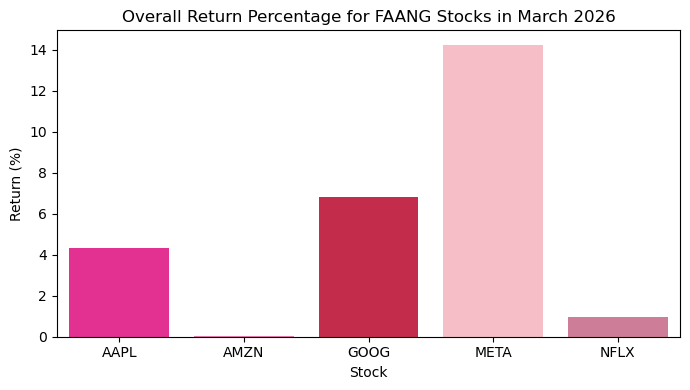

In [54]:
# b) Bar plot of returns
plt.figure(figsize=(7, 4))
sns.barplot(x=returns.index, y=returns['return_%'], hue=returns.index, palette=['deeppink', 'hotpink', 'crimson', 'lightpink', 'palevioletred'], legend=False)
plt.title('Overall Return Percentage for FAANG Stocks in March 2026')
plt.xlabel('Stock')
plt.ylabel('Return (%)')
plt.tight_layout()
plt.show()

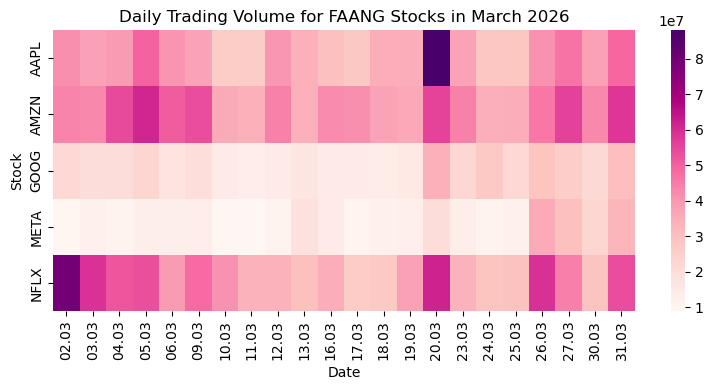

In [59]:
# c) Heatmap of daily trading volume
volume_pivot = df_stocks.pivot_table(index='symbol', columns='date', values='volume')
volume_pivot.columns = volume_pivot.columns.strftime('%d.%m')

plt.figure(figsize=(8, 4))
sns.heatmap(volume_pivot, cmap='RdPu', fmt='.0f')
plt.title('Daily Trading Volume for FAANG Stocks in March 2026')
plt.xlabel('Date')
plt.ylabel('Stock')
plt.tight_layout()
plt.show()

# Task 4: Exporting and importing data 

In [62]:
import os
import json

os.makedirs('exports', exist_ok=True)

# a) Export raw JSON data
with open('exports/stockdata.json', 'w') as f:
    json.dump(all_data, f)

# b) Export DataFrame
df_stocks.to_csv('exports/stockdata.csv', index=False)


In [63]:
# c) Load back the exported data

# Load part a data
with open('exports/stockdata.json', 'r') as f:
    loaded_json = json.load(f)
df_from_json = pd.DataFrame(loaded_json)
print("First 5 rows from JSON:")
display(df_from_json.head())

# Load part b data
df_from_csv = pd.read_csv('exports/stockdata.csv')
print("First 5 rows from CSV:")
display(df_from_csv.head())

First 5 rows from JSON:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


First 5 rows from CSV:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30 00:00:00+00:00
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27 00:00:00+00:00
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26 00:00:00+00:00
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25 00:00:00+00:00


# Task 5: Querying the Northwind database

In [64]:
import sqlite3

In [65]:
# a) Connect to the database
conn = sqlite3.connect('northwind.db')

# List all tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in Northwind database:")
for table in tables:
    print(table[0])

Tables in Northwind database:
Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [66]:
# b) Products with unit price above 30
query_b = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
"""
df_products = pd.read_sql_query(query_b, conn)
print("Products with unit price above 30:")
display(df_products)

Products with unit price above 30:


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [67]:
# c) Orders shipped to Germany
query_c = """
SELECT c.CompanyName, o.OrderID, o.OrderDate, o.ShipCountry, 
       (od.UnitPrice * od.Quantity) AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""
df_germany = pd.read_sql_query(query_c, conn)
print("Orders shipped to Germany:")
display(df_germany)

Orders shipped to Germany:


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


# Task 6: Visualizing Northwind data 

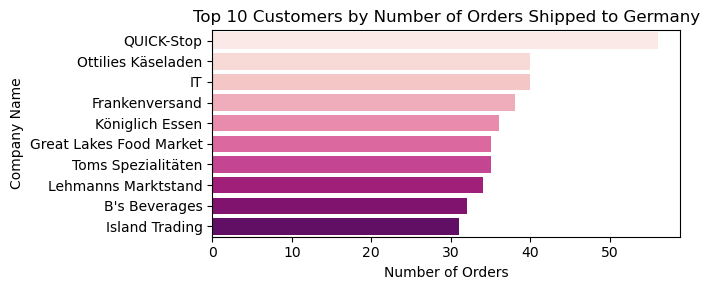

In [71]:
# a) Bar plot
orders_per_customer = df_germany.groupby('CompanyName')['OrderID'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 3))
sns.barplot(x=orders_per_customer.values, y=orders_per_customer.index, hue=orders_per_customer.index, palette='RdPu', legend=False)
plt.title('Top 10 Customers by Number of Orders Shipped to Germany')
plt.xlabel('Number of Orders')
plt.ylabel('Company Name')
plt.tight_layout()
plt.show()

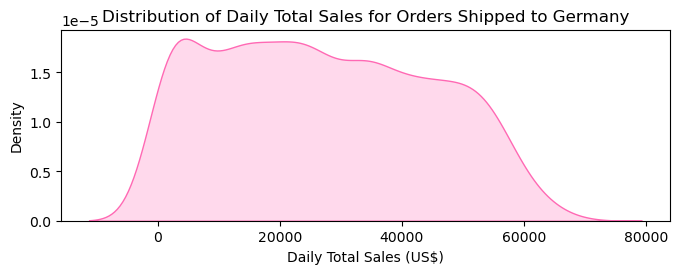

In [74]:
# b) Density plot

daily_sales = df_germany.groupby('OrderDate')['LineTotal'].sum()
plt.figure(figsize=(7, 3))
sns.kdeplot(daily_sales, fill=True, color='hotpink')
plt.title('Distribution of Daily Total Sales for Orders Shipped to Germany')
plt.xlabel('Daily Total Sales (US$)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

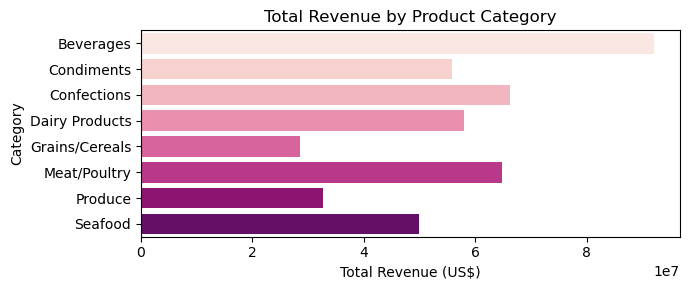

In [78]:
# c) Bar plot (revenue per product category)
query_6c = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
"""
df_revenue = pd.read_sql_query(query_6c, conn)

plt.figure(figsize=(7, 3))
sns.barplot(data=df_revenue, x='TotalRevenue', y='CategoryName', hue='CategoryName', palette='RdPu', legend=False)
plt.title('Total Revenue by Product Category')
plt.xlabel('Total Revenue (US$)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Task 7: Comparing Python to SQL

In [82]:
# a) Retrieve products & categories tables into separate DataFrames
query_products = "SELECT * FROM Products"
query_categories = "SELECT * FROM Categories"

df_products_full = pd.read_sql_query(query_products, conn)
df_categories_full = pd.read_sql_query(query_categories, conn)

display(df_products_full.head())

display(df_categories_full.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [84]:
# b) Inner join on CategoryID using pandas
df_merged = pd.merge(df_products_full, df_categories_full, on='CategoryID', how='inner')
display(df_merged.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [85]:
import time

# SQL approach (same as Task 6c)
start_sql = time.time()
df_revenue_sql = pd.read_sql_query(query_6c, conn)
end_sql = time.time()
sql_time = end_sql - start_sql

# Python/pandas approach
start_pandas = time.time()
query_od = "SELECT * FROM 'Order Details'"
query_p = "SELECT * FROM Products"
query_cat = "SELECT * FROM Categories"

df_od = pd.read_sql_query(query_od, conn)
df_p = pd.read_sql_query(query_p, conn)
df_cat = pd.read_sql_query(query_cat, conn)

df_joined = pd.merge(df_od, df_p, on='ProductID', how='inner')
df_joined = pd.merge(df_joined, df_cat, on='CategoryID', how='inner')
df_joined['LineTotal'] = df_joined['UnitPrice_x'] * df_joined['Quantity']
df_revenue_pandas = df_joined.groupby('CategoryName')['LineTotal'].sum().reset_index()
end_pandas = time.time()
pandas_time = end_pandas - start_pandas

print(f"SQL execution time: {sql_time:.4f} seconds")
print(f"Pandas execution time: {pandas_time:.4f} seconds")

if sql_time < pandas_time:
    print("SQL was faster than pandas.")
else:
    print("Pandas was faster than SQL.")

SQL execution time: 0.2505 seconds
Pandas execution time: 0.5047 seconds
SQL was faster than pandas.


# Task 8: Wide and long format

In [88]:
# Create the two datasets
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

# a) Convert wide to long format
print("Before:")
display(wide_data)

wide_to_long = pd.melt(wide_data, id_vars='store', var_name='quarter', value_name='sales')
print("After:")
display(wide_to_long)

Before:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


After:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [89]:
# b) Convert long to wide format
print("Before:")
display(long_data)

long_to_wide = long_data.pivot(index='month', columns='product', values='units_sold')
long_to_wide = long_to_wide.reset_index()
print("After:")
display(long_to_wide)

Before:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


After:


product,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [90]:
# c) Convert both back to original format

# Convert back to wide
back_to_wide = wide_to_long.pivot(index='store', columns='quarter', values='sales').reset_index()
back_to_wide.columns.name = None
print("Original wide format:")
display(back_to_wide)

# Convert back to long
back_to_long = pd.melt(long_to_wide, id_vars='month', var_name='product', value_name='units_sold')
back_to_long = back_to_long.sort_values('month').reset_index(drop=True)
print("Original long format:")
display(back_to_long)

Original wide format:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Original long format:


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130
